In [17]:
# missing values
from pyexpat import model
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
import numpy as np


In [4]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame
print(f"Duplicate values of dataset: {df.duplicated().sum()}")
print(f"Missing value of dataset: {df.isnull().sum()}")

Duplicate values of dataset: 0
Missing value of dataset: MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [13]:

# feature scaling   
target = df['MedHouseVal']
features = df.drop('MedHouseVal', axis=1)
X_temp, X_test, y_temp, Y_test = train_test_split(
    features, target, test_size=0.25, random_state=42
)
x_train, x_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)

In [14]:
# model = LinearRegression()
rf = RandomForestRegressor(random_state=42)
rf.fit(x_valid, y_valid)
# model.fit(x_train, y_train)  


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

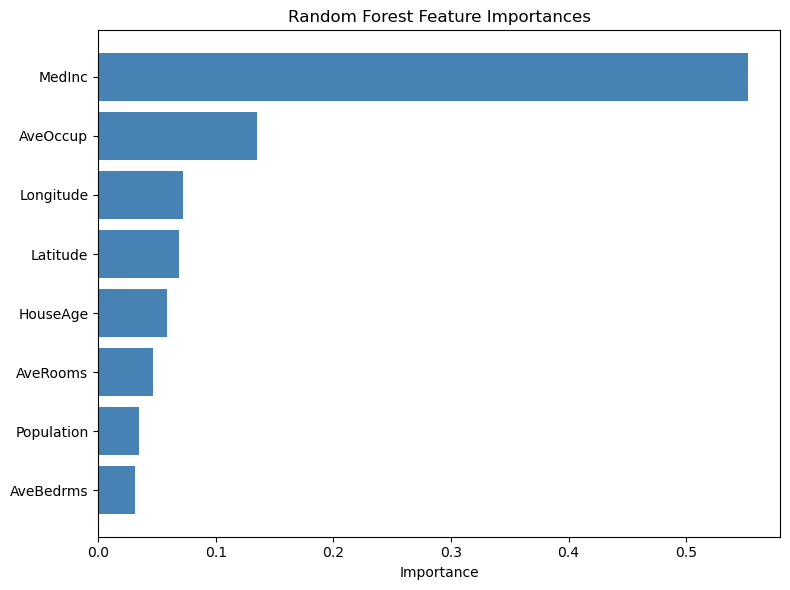

In [15]:
importance = rf.feature_importances_ 
# Assuming x_train is a DataFrame so we have the feature names 
feature_names = x_train.columns # Put importances into a DataFrame for easy sorting 
importance_df = pd.DataFrame({ 'feature': feature_names, 'importance': importance }).sort_values(by='importance', ascending=True) 
# ascending for a nice horizontal barh order 
plt.figure(figsize=(8, 6)) 
plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue') 
plt.xlabel('Importance')
plt.title('Random Forest Feature Importances') 
plt.tight_layout() 
plt.show()


In [24]:
# Calculate performance metrics
predictions_rf_tuned_val = rf.predict(x_valid)

mse_rf_tuned = mean_squared_error(y_valid, predictions_rf_tuned_val)
rmse_rf_tuned = np.sqrt(mse_rf_tuned)
r2_rf_tuned = rf.score(x_valid, y_valid)

print("=== RANDOM FOREST REGRESSION PERFORMANCE ===")
print()
print("Hyperparameters used:")
print(f"Number of trees: {rf.n_estimators}")
print(f"Max Depth: {rf.max_depth}")
print(f"Min Samples Split: {rf.min_samples_split}")
print(f"Min Samples Leaf: {rf.min_samples_leaf}")
print(f"Max Features: {rf.max_features}")
print("Metrics:")
print(f"MSE:  {mse_rf_tuned:.4f}")
print(f"RMSE: {rmse_rf_tuned:.4f}")
print(f"R²:   {r2_rf_tuned:.1%}")
print()

=== RANDOM FOREST REGRESSION PERFORMANCE ===

Hyperparameters used:
Number of trees: 100
Max Depth: None
Min Samples Split: 2
Min Samples Leaf: 1
Max Features: 1.0
Metrics:
MSE:  0.0431
RMSE: 0.2077
R²:   96.7%



In [37]:
best_r2 = float('-inf')
best_params = {}
best_model = None
param_grid = {
    'max_depth': [2, 5, 10, 15, 50],
    'min_samples_split': [2, 10, 20],
    'n_estimators': [100, 200]
}
for max_depth in param_grid['max_depth']:
    for min_samples_split in param_grid['min_samples_split']:
        for n_estimators in param_grid['n_estimators']:
            rf_tuned = RandomForestRegressor(
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                n_estimators=n_estimators,
                random_state=42
            )
            rf_tuned.fit(x_valid, y_valid)
            predictions_rf_tuned_val = rf_tuned.predict(x_valid)
            r2_rf_tuned = rf_tuned.score(x_valid, y_valid)

            if r2_rf_tuned > best_r2:
                best_r2 = r2_rf_tuned
                best_params = {
                    'max_depth': max_depth,
                    'min_samples_split': min_samples_split,
                    'n_estimators': n_estimators
                }
                best_model = rf_tuned

print("=== OPTIMIZED RANDOM FOREST PERFORMANCE ===")
print(f"R²: {best_r2:.1%}")
print(f"Best max_depth: {best_params['max_depth']}")
print(f"Best min_samples_split: {best_params['min_samples_split']}")
print(f"Best n_estimators: {best_params['n_estimators']}")

=== OPTIMIZED RANDOM FOREST PERFORMANCE ===
R²: 96.8%
Best max_depth: 50
Best min_samples_split: 2
Best n_estimators: 200
